# Student productivity — exploratory analysis

Synthetic cohort (~20&nbsp;k rows). Inspect columns, apply the same light cleaning as `app.py`, then sample plots and a correlation matrix.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
df = pd.read_csv("student_productivity.csv")
df.head()

,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,productivity_score,final_grade
0,1,25,Male,4.31,5.64,7.60,3.34,2.41,0.35,9,448 mg,25.0,8,72.49%,9,13.55,40.08,86.92
1,2,26,Female,7.62,4.42,5.24,2.00,2.36,1.22,6,440 mg,33.0,11,88.00%,8,18.53,44.04,64.36
2,3,28,Male,1.38,6.78,9.82,3.87,2.82,2.70,10,402 mg,49.0,0,52.86%,8,0.00,23.48,77.78
3,4,21,Female,5.37,6.66,11.05,5.29,3.03,3.36,9,478 mg,39.0,10,75.52%,8,16.88,27.07,74.69
4,5,17,Male,6.00,7.54,1.37,1.22,0.41,0.00,9,214 mg,57.0,10,77.56%,5,46.65,81.66,73.66


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             20000 non-null  int64  
 1   age                    20000 non-null  int64  
 2   gender                 20000 non-null  object 
 3   study_hours_per_day    20000 non-null  float64
 4   sleep_hours            20000 non-null  float64
 5   phone_usage_hours      19791 non-null  float64
 6   social_media_hours     20000 non-null  float64
 7   youtube_hours          20000 non-null  float64
 8   gaming_hours           20000 non-null  float64
 9   breaks_per_day         20000 non-null  int64  
 10  coffee_intake_mg       19450 non-null  object 
 11  exercise_minutes       19700 non-null  float64
 12  assignments_completed  20000 non-null  int64  
 13  attendance_percentage  20000 non-null  object 
 14  stress_level           20000 non-null  int64  
 15  fo

In [4]:
df.describe()

,student_id,age,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,exercise_minutes,assignments_completed,stress_level,focus_score,productivity_score,final_grade
count,20000.000000,20000.000000,20000.000000,20000.000000,19791.000000,20000.000000,20000.000000,20000.000000,20000.000000,19700.000000,20000.00000,20000.000000,20000.000000,20000.000000,19868.000000
mean,10000.500000,23.516550,5.519818,6.397368,5.829579,2.633289,1.765046,2.056907,6.979750,51.268883,10.04240,6.548500,23.066429,55.361234,71.949085
std,5773.647028,4.012671,2.222068,1.119173,3.031510,1.434752,1.046025,1.311389,2.773234,25.627816,4.97107,2.113497,18.336853,24.409231,12.364577
min,1.000000,17.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000,0.000000,35.000000
25%,5000.750000,20.000000,3.780000,5.610000,3.430000,1.510000,0.960000,1.040000,5.000000,33.000000,6.00000,5.000000,5.787500,35.890000,63.470000
50%,10000.500000,24.000000,5.500000,6.410000,5.880000,2.640000,1.760000,2.010000,7.000000,52.000000,10.00000,7.000000,21.530000,54.280000,72.005000
75%,15000.250000,27.000000,7.280000,7.190000,8.240000,3.740000,2.530000,2.980000,9.000000,69.000000,14.00000,8.000000,37.670000,74.792500,80.610000
max,20000.000000,30.000000,11.250000,10.000000,12.000000,6.660000,5.210000,6.000000,15.000000,145.000000,20.00000,10.000000,78.990000,100.000000,100.000000


## Cleaning

Parse `coffee_intake_mg` and `attendance_percentage`, impute a few numeric gaps with column means, drop `student_id`.


In [6]:
# Strip " mg" and convert coffee_intake_mg to numeric (float).
df["coffee_intake_mg"] = pd.to_numeric(
    df["coffee_intake_mg"].str.replace(" mg", "", regex=False),
    errors="coerce",
)

In [8]:
df.coffee_intake_mg.describe()

count    19450.000000
mean       347.046478
std        104.551971
min          0.000000
25%        272.000000
50%        347.000000
75%        423.000000
max        600.000000
Name: coffee_intake_mg, dtype: float64

In [9]:
# Fill missing values with each column's mean (numeric columns only).
cols_with_mean = [
    "phone_usage_hours",
    "coffee_intake_mg",
    "exercise_minutes",
    "final_grade",
]
for col in cols_with_mean:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mean())

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             20000 non-null  int64  
 1   age                    20000 non-null  int64  
 2   gender                 20000 non-null  object 
 3   study_hours_per_day    20000 non-null  float64
 4   sleep_hours            20000 non-null  float64
 5   phone_usage_hours      20000 non-null  float64
 6   social_media_hours     20000 non-null  float64
 7   youtube_hours          20000 non-null  float64
 8   gaming_hours           20000 non-null  float64
 9   breaks_per_day         20000 non-null  int64  
 10  coffee_intake_mg       20000 non-null  float64
 11  exercise_minutes       20000 non-null  float64
 12  assignments_completed  20000 non-null  int64  
 13  attendance_percentage  20000 non-null  object 
 14  stress_level           20000 non-null  int64  
 15  fo

In [11]:
df.gender.unique()

array(['Male', 'Female', 'F', 'Other', 'M'], dtype=object)

In [12]:
# Standardize gender: M -> Male, F -> Female.
df["gender"] = df["gender"].replace({"M": "Male", "F": "Female"})

In [13]:
df.gender.unique()

array(['Male', 'Female', 'Other'], dtype=object)

In [14]:
df.attendance_percentage

0        72.49%
1        88.00%
2        52.86%
3        75.52%
4        77.56%
          ...  
19995    72.85%
19996    87.69%
19997    58.80%
19998    53.93%
19999    95.13%
Name: attendance_percentage, Length: 20000, dtype: object

In [15]:
# Strip "%" and convert attendance_percentage to numeric (float).
df["attendance_percentage"] = pd.to_numeric(
    df["attendance_percentage"].str.rstrip("%"),
    errors="coerce",
)

In [17]:
df.attendance_percentage.describe()

count    20000.000000
mean        75.074253
std         12.849057
min         40.000000
25%         65.190000
50%         75.010000
75%         84.912500
max        100.000000
Name: attendance_percentage, dtype: float64

In [18]:
df = df.drop(columns=["student_id"])

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    20000 non-null  int64  
 1   gender                 20000 non-null  object 
 2   study_hours_per_day    20000 non-null  float64
 3   sleep_hours            20000 non-null  float64
 4   phone_usage_hours      20000 non-null  float64
 5   social_media_hours     20000 non-null  float64
 6   youtube_hours          20000 non-null  float64
 7   gaming_hours           20000 non-null  float64
 8   breaks_per_day         20000 non-null  int64  
 9   coffee_intake_mg       20000 non-null  float64
 10  exercise_minutes       20000 non-null  float64
 11  assignments_completed  20000 non-null  int64  
 12  attendance_percentage  20000 non-null  float64
 13  stress_level           20000 non-null  int64  
 14  focus_score            20000 non-null  float64
 15  pr

## Univariate checks

Histogram + KDE and boxplots for numeric columns.


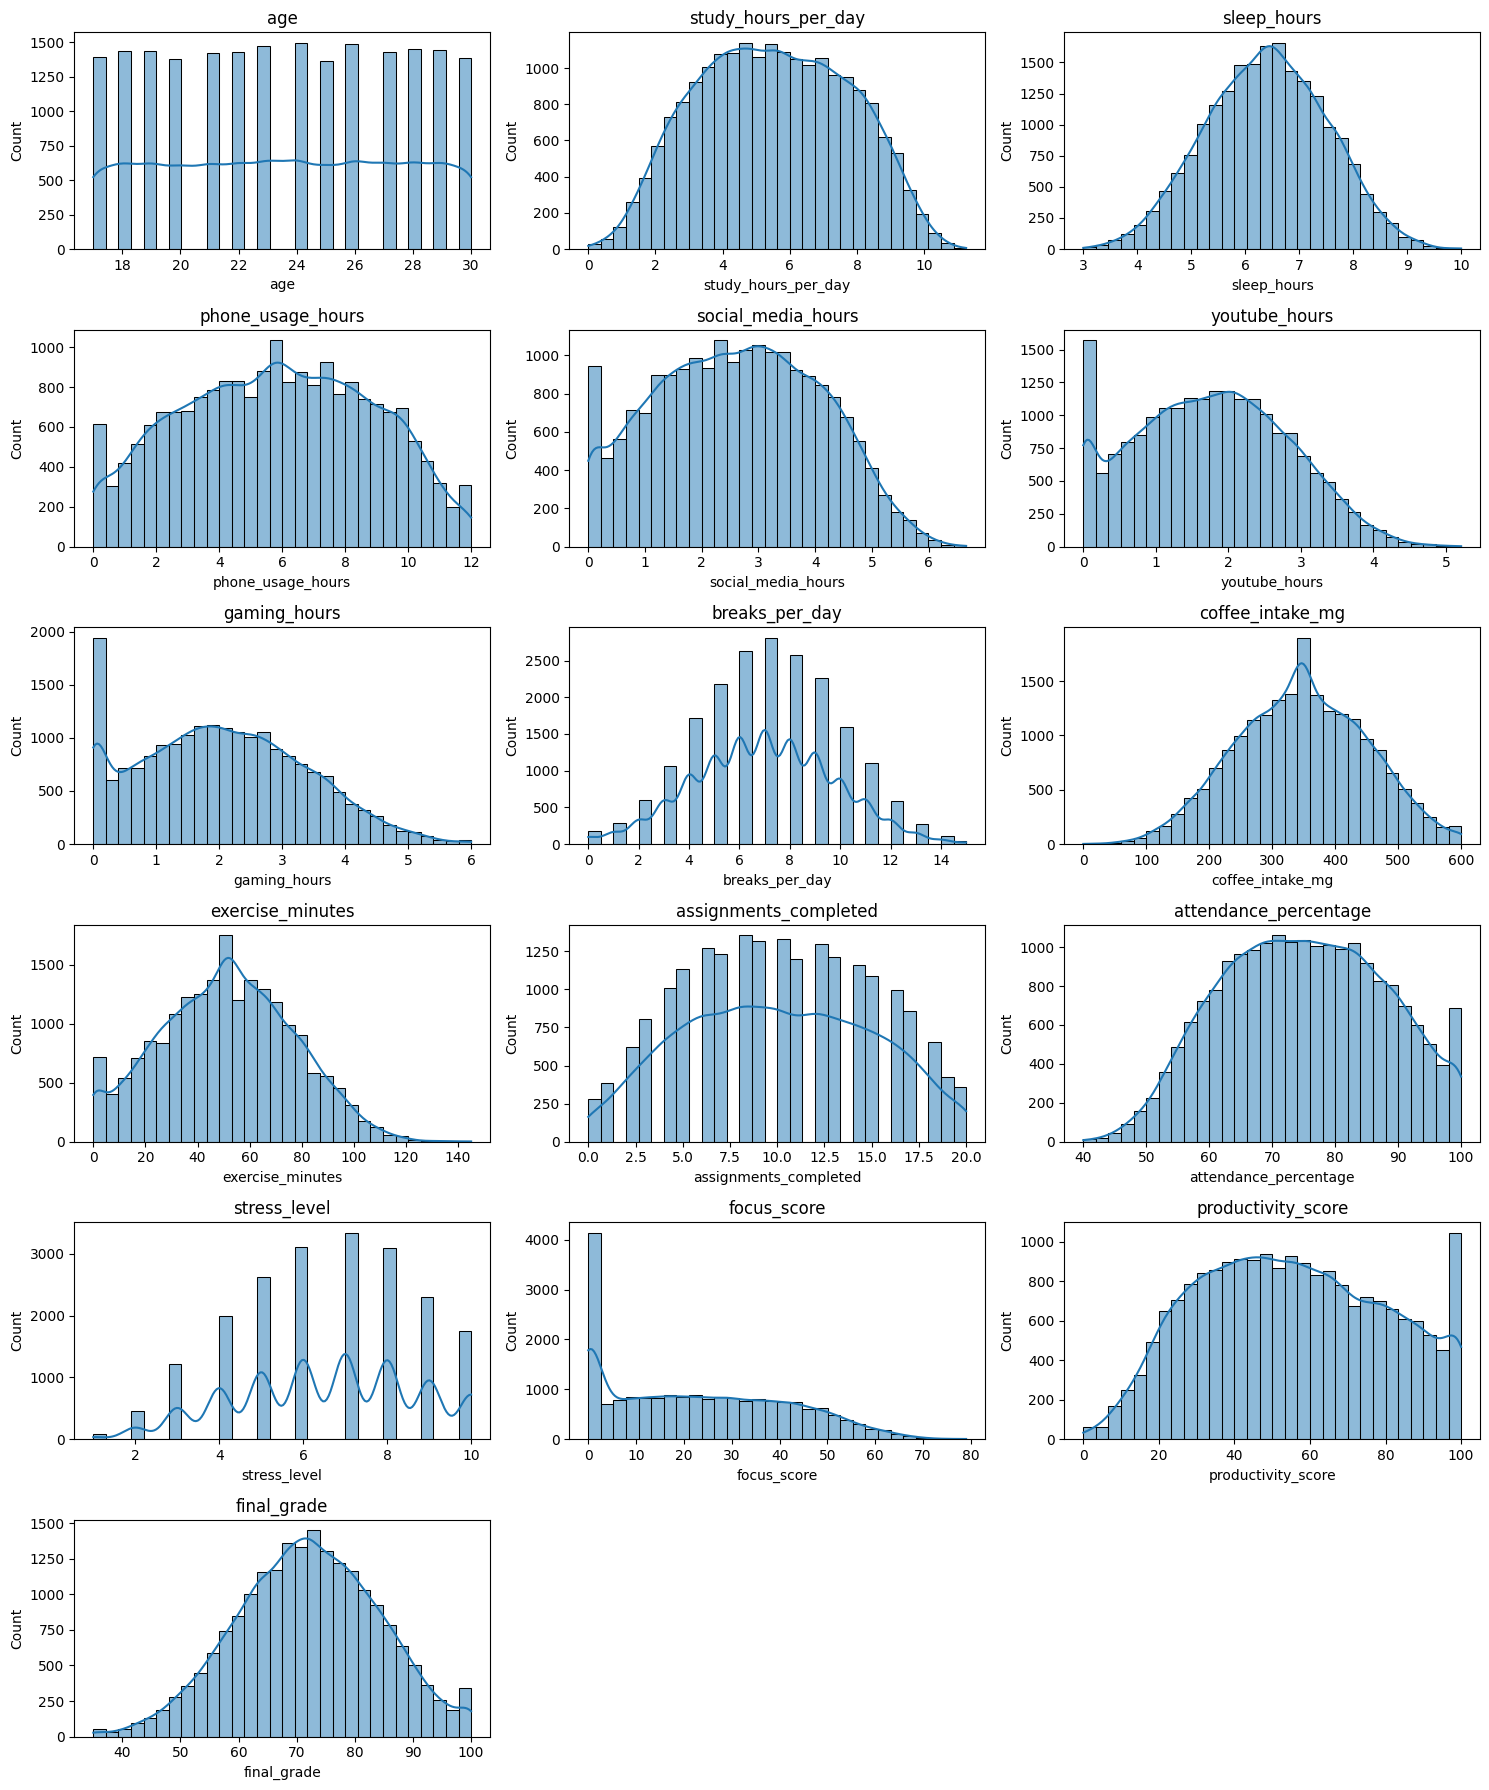

In [28]:
cols = df.select_dtypes(include="number").columns.tolist()
ncols = 3
nrows = (len(cols) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3 * nrows))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(df[col].dropna(), kde=True, bins=30, ax=axes[i])
    axes[i].set_title(col)

for j in range(len(cols), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

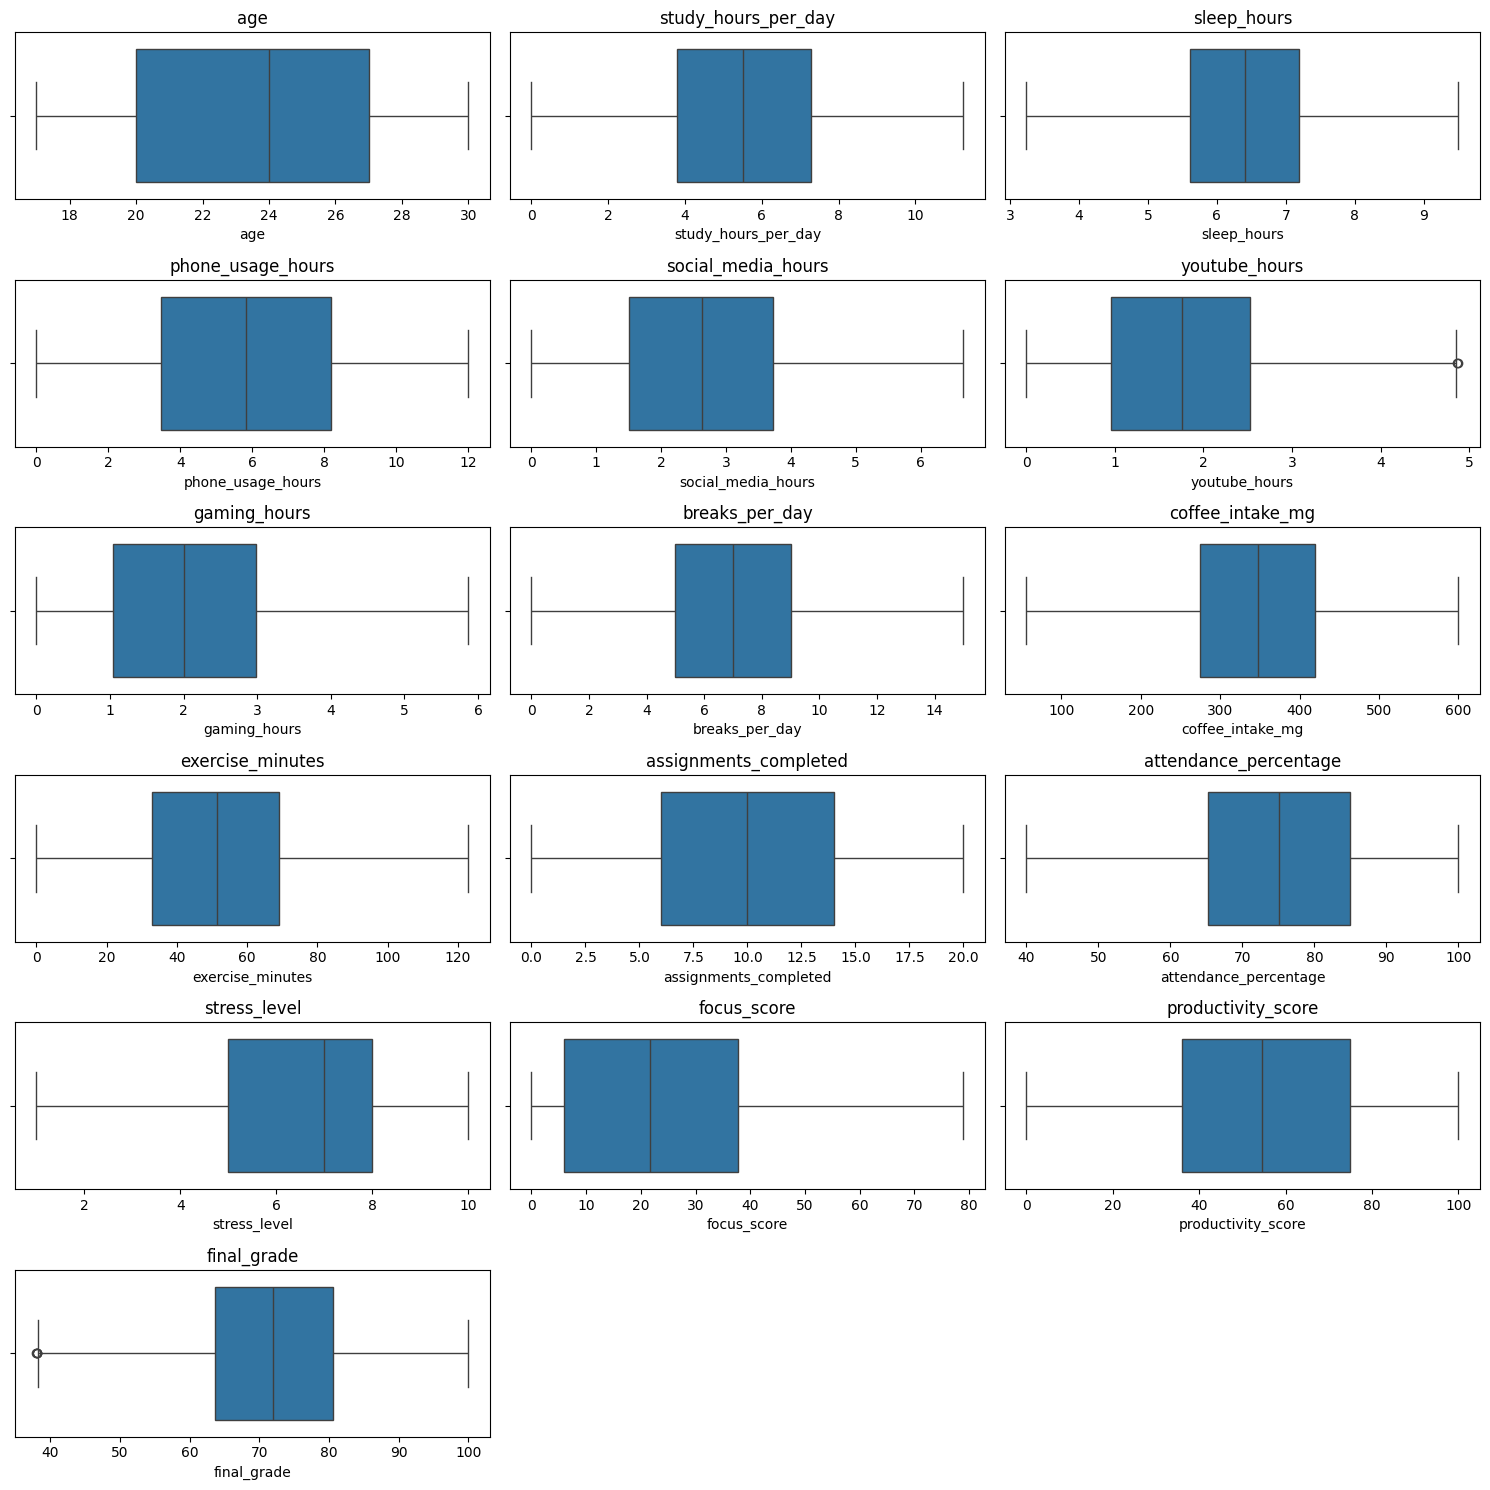

In [30]:
cols = df.select_dtypes(include="number").columns.tolist()
ncols, nrows = 3, (len(cols) + 2) // 3
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 2.5 * nrows))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)

for j in range(len(cols), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

## Pairwise slices

Examples of joint behaviour (density, scatter, boxes, regression).


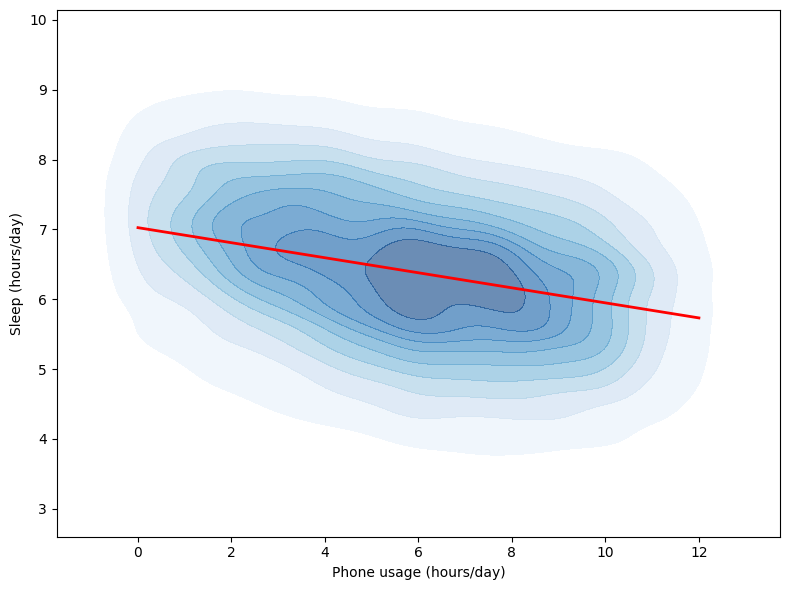

In [35]:
plt.figure(figsize=(8, 6))
sns.kdeplot(
    data=df, x="phone_usage_hours", y="sleep_hours",
    fill=True, thresh=0.05, alpha=0.6, cmap="Blues",
)
sns.regplot(
    data=df, x="phone_usage_hours", y="sleep_hours",
    scatter=False,
    line_kws={"color": "red", "linewidth": 2},
    ci=None,
)
plt.xlabel("Phone usage (hours/day)")
plt.ylabel("Sleep (hours/day)")
plt.tight_layout()
plt.show()

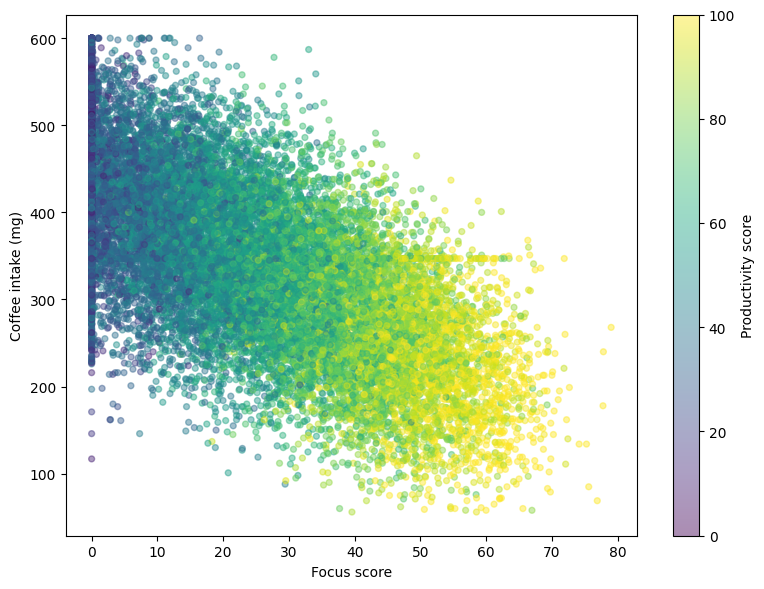

In [36]:
plt.figure(figsize=(8, 6))
sc = plt.scatter(
    df["focus_score"],
    df["coffee_intake_mg"],
    c=df["productivity_score"],
    cmap="viridis",
    alpha=0.45,
    s=18,
)
plt.colorbar(sc, label="Productivity score")
plt.xlabel("Focus score")
plt.ylabel("Coffee intake (mg)")
plt.tight_layout()
plt.show()

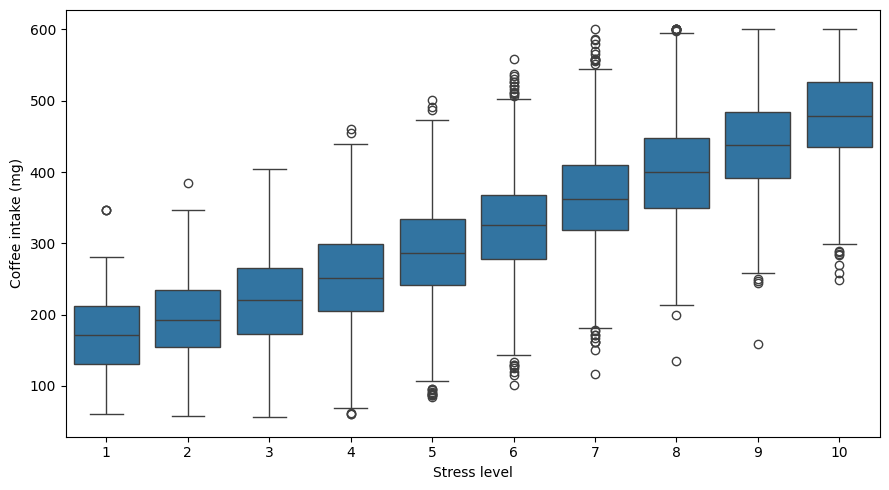

In [37]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="stress_level", y="coffee_intake_mg")
plt.xlabel("Stress level")
plt.ylabel("Coffee intake (mg)")
plt.tight_layout()
plt.show()

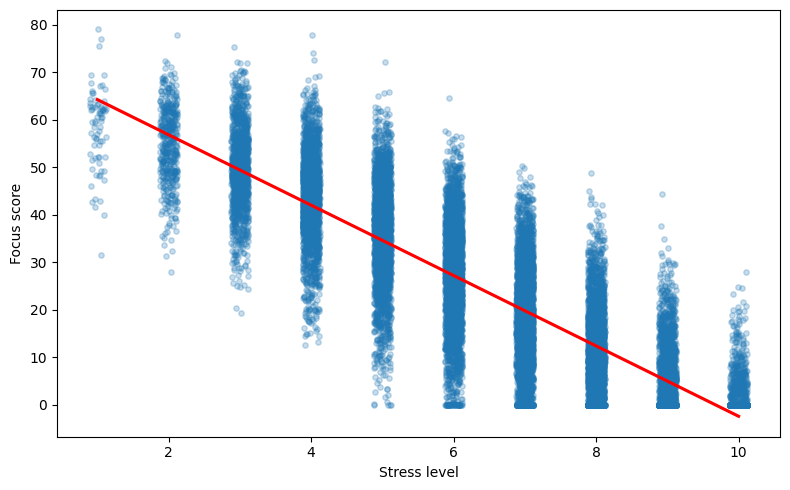

In [38]:
plt.figure(figsize=(8, 5))
sns.regplot(
    data=df,
    x="stress_level",
    y="focus_score",
    x_jitter=0.12,
    scatter_kws={"alpha": 0.25, "s": 15},
    line_kws={"color": "red"},
)
plt.xlabel("Stress level")
plt.ylabel("Focus score")
plt.tight_layout()
plt.show()

## Screen time vs stress

Entertainment screen hours (social + YouTube + gaming) by self-reported stress level.


/var/folders/1z/695r5vjj25925ssfxxwjpmw80000gn/T/ipykernel_84056/2944327487.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


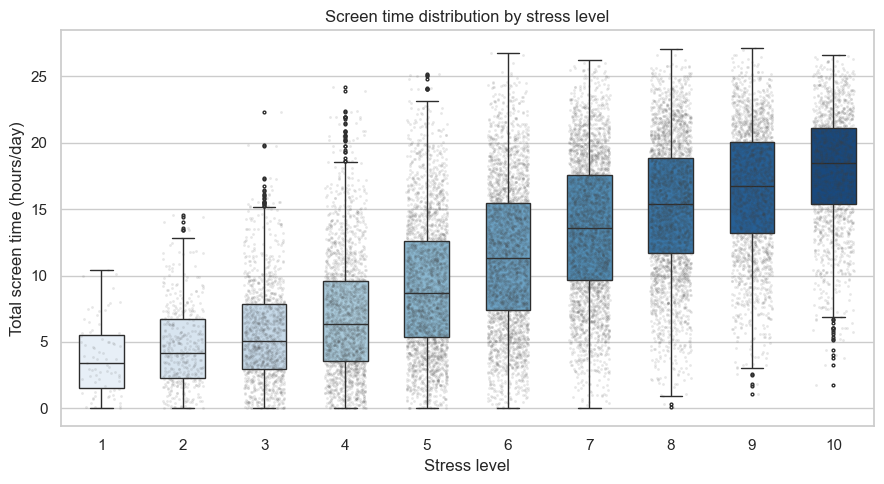

In [83]:
d = df.assign(
    total_screen_hours=df["social_media_hours"] + df["youtube_hours"] + df["gaming_hours"]
)

sns.set_theme(style="whitegrid", context="notebook")
plt.figure(figsize=(9, 5))
ax = sns.boxplot(
    data=d,
    x="stress_level",
    y="total_screen_hours",
    palette="Blues",
    width=0.55,
    fliersize=2,
)
sns.stripplot(
    data=d,
    x="stress_level",
    y="total_screen_hours",
    color="0.25",
    alpha=0.12,
    size=2,
    jitter=0.25,
    ax=ax,
)
plt.xlabel("Stress level")
plt.ylabel("Total screen time (hours/day)")
plt.title("Screen time distribution by stress level")
plt.tight_layout()
plt.show()

## Assignments vs grade (by exercise)

Exercise minutes split into tertiles; lines show mean final grade vs assignments completed.


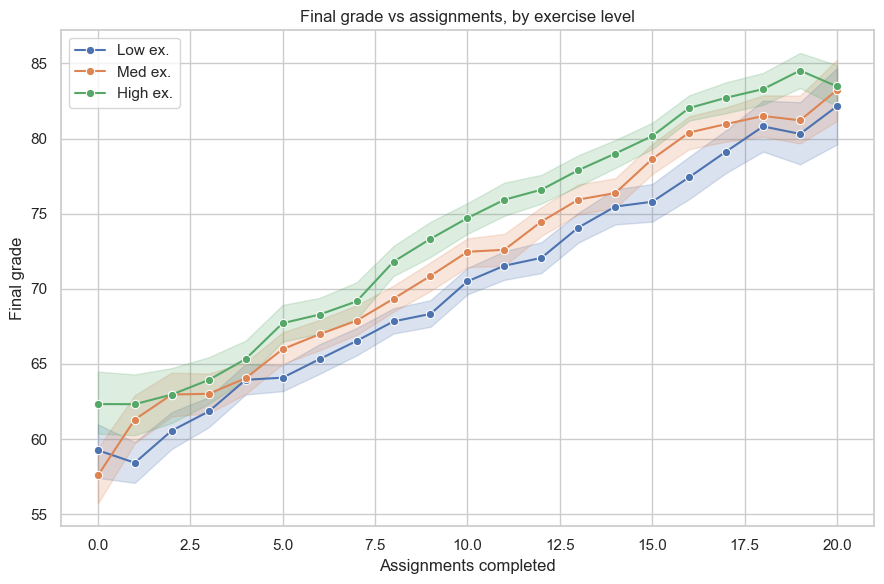

In [46]:
df = df.copy()
df["exercise_group"] = pd.qcut(
    df["exercise_minutes"], q=3, labels=["Low ex.", "Med ex.", "High ex."]
)
sns.set_theme(style="whitegrid", context="notebook")
plt.figure(figsize=(9, 6))
sns.lineplot(
    data=df,
    x="assignments_completed",
    y="final_grade",
    hue="exercise_group",
    err_style="band",
    marker="o",
    markersize=6,
)
plt.xlabel("Assignments completed")
plt.ylabel("Final grade")
plt.title("Final grade vs assignments, by exercise level")
plt.legend(title="")
plt.tight_layout()

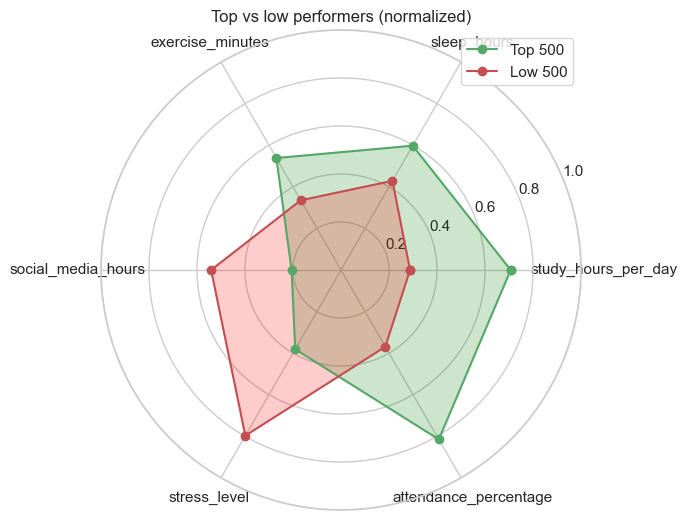

In [54]:
from sklearn.preprocessing import MinMaxScaler

vars_ = ["study_hours_per_day", "sleep_hours", "exercise_minutes",
         "social_media_hours", "stress_level", "attendance_percentage"]

# Scale all variables to 0-1 so they're comparable on the radar.
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df[vars_])
df_scaled = pd.DataFrame(scaled, columns=vars_)

top_idx = df.nlargest(500, "final_grade").index
low_idx = df.nsmallest(500, "final_grade").index

top_means = df_scaled.loc[top_idx, vars_].mean().tolist()
low_means = df_scaled.loc[low_idx, vars_].mean().tolist()

angles = np.linspace(0, 2 * np.pi, len(vars_), endpoint=False).tolist()
top_means += top_means[:1]; low_means += low_means[:1]; angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.plot(angles, top_means, "g-o", label="Top 500")
ax.fill(angles, top_means, alpha=0.2, color="green")
ax.plot(angles, low_means, "r-o", label="Low 500")
ax.fill(angles, low_means, alpha=0.2, color="red")
ax.set_thetagrids(np.degrees(angles[:-1]), vars_)
ax.set_ylim(0, 1)
ax.legend(loc="upper right")
plt.title("Top vs low performers (normalized)")
plt.tight_layout()
plt.show()

## Grade × sleep bands

Cut final grade (Low/Mid/High) and sleep into tertiles; sunburst shows counts (colour encodes a tier index).


In [ ]:
prep = df[["final_grade", "sleep_hours", "productivity_score"]].apply(
    pd.to_numeric, errors="coerce"
).dropna()

prep["grade_band"] = pd.cut(
    prep["final_grade"],
    [0, 60, 75, 100],
    labels=["Low", "Mid", "High"],
)
prep["sleep_band"] = pd.qcut(
    prep["sleep_hours"], 3, labels=["Short", "Med", "Long"], duplicates="drop"
)

agg = prep.groupby(["grade_band", "sleep_band"], observed=False).agg(
    students=("final_grade", "count"),
    avg_final=("final_grade", "mean"),
    avg_productivity=("productivity_score", "mean"),
).reset_index()

g = {"Low": 0, "Mid": 1, "High": 2}
s = {"Short": 0, "Med": 1, "Long": 2}
agg["tier"] = (
    agg["grade_band"].astype(str).map(g).astype(int) * 3
    + agg["sleep_band"].astype(str).map(s).astype(int)
)

fig = px.sunburst(
    agg,
    path=["grade_band", "sleep_band"],
    values="students",
    color="tier",
    color_continuous_scale="Cividis",
    range_color=[0, 8],
    hover_data={"avg_final": ":.1f", "avg_productivity": ":.1f"},
    title="Grade → sleep",
)
fig.update_traces(textinfo="label+percent entry")
fig.update_layout(margin=dict(t=45, l=8, r=8, b=8))
fig.show()

## Correlation matrix

Pearson *r* among habits and outcomes (lower triangle).


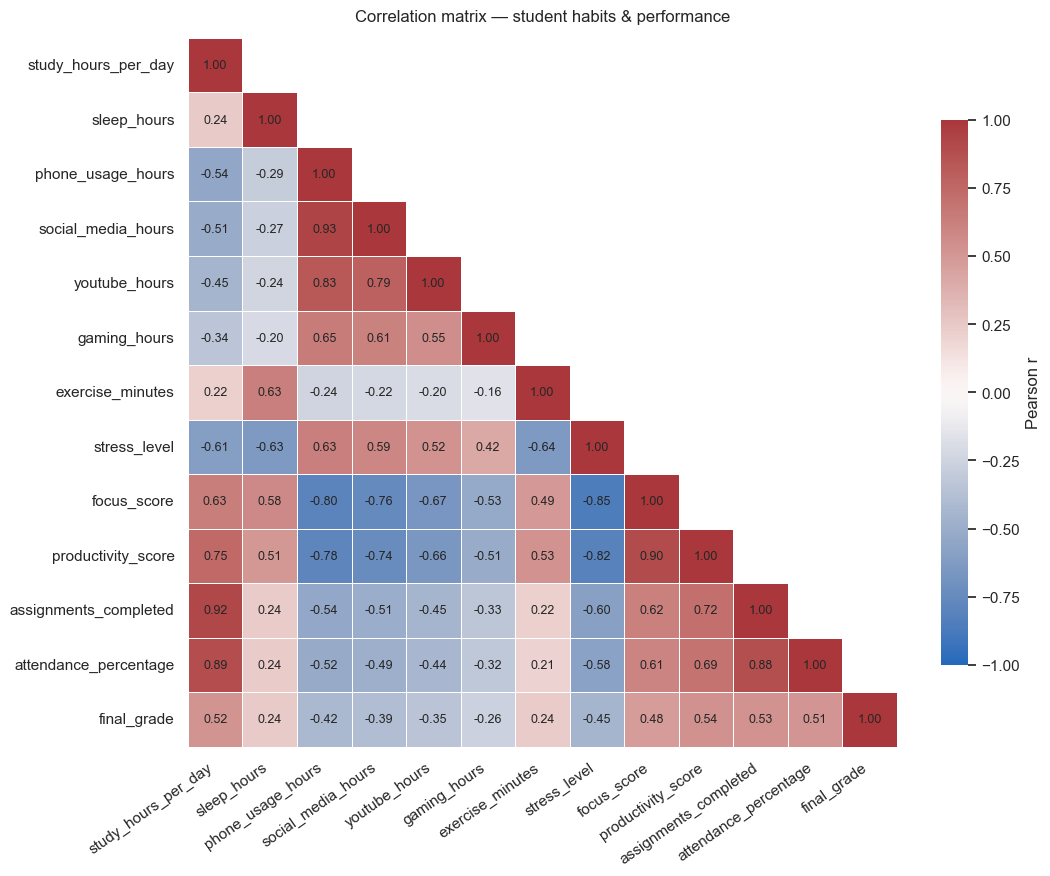

In [62]:
sns.set_theme(style="white", context="notebook")

# Core variables aligned with your proposal (digital, study, wellness, outcomes).
corr_cols = [
    "study_hours_per_day",
    "sleep_hours",
    "phone_usage_hours",
    "social_media_hours",
    "youtube_hours",
    "gaming_hours",
    "exercise_minutes",
    "stress_level",
    "focus_score",
    "productivity_score",
    "assignments_completed",
    "attendance_percentage",
    "final_grade",
]

c = df[corr_cols].corr(numeric_only=True)
mask = np.triu(np.ones_like(c, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    c,
    mask=mask,
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.6,
    linecolor="white",
    annot=True,
    fmt=".2f",
    annot_kws={"size": 9, "color": "0.15"},
    cbar_kws={"shrink": 0.75, "label": "Pearson r"},
    ax=ax,
)
ax.set_title("Correlation matrix — student habits & performance", pad=12)
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()